# 02: Symbolic Encoder Training (S1, S2, S3)

Train three symbolic encoder strategies on Thunder Compute:
- **S1**: BERT-style Transformer on REMI tokens (TransformerSymbolicEncoder)
- **S2**: GNN on score graph (GNNSymbolicEncoder)
- **S3**: 1D-CNN + Transformer on continuous features (ContinuousSymbolicEncoder)

Each model has a pretrain stage (self-supervised) and finetune stage (supervised ranking).

---

## 1. Setup

In [21]:
import subprocess
import sys
import os
import torch
if torch.cuda.is_available():
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
torch.set_float32_matmul_precision('medium')
torch.set_num_threads(os.cpu_count())

if os.path.exists('/workspace'):
    !curl -fsSL https://rclone.org/install.sh | sudo bash 2>&1 | grep -E '(successfully|already)' || echo 'rclone installed'

In [22]:
from pathlib import Path

IS_CLOUD = Path('/workspace').exists()

if IS_CLOUD:
    get_ipython().system('git clone https://github.com/Jai-Dhiman/crescendAI.git /workspace/crescendai')
    get_ipython().run_line_magic('cd', '/workspace/crescendai/model')
    get_ipython().system('curl -LsSf https://astral.sh/uv/install.sh | sh')
    get_ipython().system(f'uv pip install -e . --python {sys.executable}')
    get_ipython().system('rclone sync gdrive:crescendai_data/model_improvement/data/percepiano_cache ./data/percepiano_cache --progress')
    get_ipython().system('rclone sync gdrive:crescendai_data/model_improvement/data/pretrain_cache ./data/pretrain_cache --progress')
    get_ipython().system("rclone copy gdrive:crescendai_data/model_improvement/data/composite_labels ../data/composite_labels --progress 2>/dev/null || echo 'composite_labels: using local copy'")
    # Download existing checkpoints so training can resume from where it left off
    get_ipython().system('rclone copy gdrive:crescendai_data/model_improvement/checkpoints/ ./data/checkpoints/model_improvement/ --progress')
else:
    _nb_dir = Path.cwd()
    _model_dir = _nb_dir
    while _model_dir.name != 'model' and _model_dir != _model_dir.parent:
        _model_dir = _model_dir.parent
    if _model_dir.name == 'model':
        get_ipython().run_line_magic('cd', str(_model_dir))

DATA_DIR = Path('data')
CHECKPOINT_DIR = Path('data/checkpoints/model_improvement')
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# --- Memory-aware configuration ---
LOW_MEMORY = not torch.cuda.is_available()
_PIN_MEMORY = torch.cuda.is_available()

if LOW_MEMORY:
    S1_PRETRAIN_BATCH = 8;   S1_FINETUNE_BATCH = 16;  S1_MAX_SEQ_LEN = 1024
    S2_PRETRAIN_BATCH = 8;   S2_FINETUNE_BATCH = 32
    S2H_PRETRAIN_BATCH = 8;  S2H_FINETUNE_BATCH = 32
    S3_PRETRAIN_BATCH = 8;   S3_FINETUNE_BATCH = 16;  S3_MAX_SEQ_LEN = 1024
    ACCUM_BATCHES = 8;       ACCUM_BATCHES_GNN = 2
else:
    S1_PRETRAIN_BATCH = 64;  S1_FINETUNE_BATCH = 64;  S1_MAX_SEQ_LEN = 2048
    S2_PRETRAIN_BATCH = 16;  S2_FINETUNE_BATCH = 64
    S2H_PRETRAIN_BATCH = 8;  S2H_FINETUNE_BATCH = 64
    S3_PRETRAIN_BATCH = 64;  S3_FINETUNE_BATCH = 64;  S3_MAX_SEQ_LEN = 2000
    ACCUM_BATCHES = 1;       ACCUM_BATCHES_GNN = 4

# Download checkpoints from GDrive if rclone available (works on both cloud and local)
import shutil
if not IS_CLOUD and shutil.which('rclone'):
    get_ipython().system(f'rclone copy gdrive:crescendai_data/model_improvement/checkpoints/ {CHECKPOINT_DIR}/ --progress')

print(f'DATA_DIR: {DATA_DIR.resolve()}')
print(f'CHECKPOINT_DIR: {CHECKPOINT_DIR.resolve()}')
print(f'Running on: {"cloud" if IS_CLOUD else "local"}')
print(f'LOW_MEMORY: {LOW_MEMORY}  PIN_MEMORY: {_PIN_MEMORY}')

/Users/jdhiman/Documents/crescendai/model
Transferred:   	          0 B / 0 B, -, 0 B/s, ETA -
Checks:                 1 / 1, 100%, Listed 72
Elapsed time:         0.4sTransferred:   	          0 B / 0 B, -, 0 B/s, ETA -
Checks:                20 / 20, 100%, Listed 102
Elapsed time:         0.9s
DATA_DIR: /Users/jdhiman/Documents/crescendai/model/data
CHECKPOINT_DIR: /Users/jdhiman/Documents/crescendai/model/data/checkpoints/model_improvement
Running on: local
LOW_MEMORY: True  PIN_MEMORY: False


In [23]:
import json
import numpy as np
import torch
import pytorch_lightning as pl
from functools import partial
from torch.utils.data import DataLoader

sys.path.insert(0, 'src')

from model_improvement.symbolic_encoders import (
    TransformerSymbolicEncoder,
    GNNSymbolicEncoder,
    GNNHeteroSymbolicEncoder,
    ContinuousSymbolicEncoder,
)
from model_improvement.tokenizer import PianoTokenizer, extract_continuous_features
from model_improvement.data import (
    MIDIPretrainingDataset,
    PairedPerformanceDataset,
    ScoreGraphPretrainingDataset,
    ContinuousPretrainDataset,
    HeteroPretrainDataset,
    ShardedScoreGraphPretrainDataset,
    ShardedHeteroPretrainDataset,
    ShardedContinuousPretrainDataset,
    graph_pair_collate_fn,
    graph_pretrain_collate_fn,
    symbolic_collate_fn,
    continuous_collate_fn,
    hetero_graph_collate_fn,
    hetero_pretrain_collate_fn,
    multi_task_collate_fn,
)
from model_improvement.graph import midi_to_graph, midi_to_hetero_graph
from model_improvement.training import train_model, upload_checkpoint, find_checkpoint
from model_improvement.taxonomy import load_composite_labels, NUM_DIMS, DIMENSIONS
from model_improvement.evaluation import (
    evaluate_model, aggregate_folds, run_robustness_check,
    select_winner, ROBUSTNESS_VETO_THRESHOLD,
)
from model_improvement.metrics import compute_robustness_metrics, format_comparison_table
import matplotlib.pyplot as plt

## 2. Load Data

In [24]:
cache_dir = DATA_DIR / 'percepiano_cache'

# Load 6-dim composite labels (teacher-grounded taxonomy)
composite_path = DATA_DIR / 'composite_labels' / 'composite_labels.json'
labels_raw = load_composite_labels(composite_path)
labels = {k: v.tolist() for k, v in labels_raw.items()}
print(f'Loaded {len(labels)} composite labels ({NUM_DIMS} dims: {DIMENSIONS})')

with open(cache_dir / 'folds.json') as f:
    folds = json.load(f)

with open(cache_dir / 'piece_mapping.json') as f:
    piece_to_keys = json.load(f)

print(f'Folds: {len(folds)}')
for i, fold in enumerate(folds):
    print(f'  Fold {i}: {len(fold["train"])} train, {len(fold["val"])} val')

Loaded 1202 composite labels (6 dims: ['dynamics', 'timing', 'pedaling', 'articulation', 'phrasing', 'interpretation'])
Folds: 4
  Fold 0: 758 train, 263 val
  Fold 1: 787 train, 234 val
  Fold 2: 766 train, 255 val
  Fold 3: 752 train, 269 val


## 3. Prepare Symbolic Inputs

In [25]:
print('Loading pretrain cache for S1 (tokenized sequences)...')

pretrain_dir = DATA_DIR / 'pretrain_cache'
if not pretrain_dir.exists():
    raise FileNotFoundError(
        f'Pretrain cache not found at {pretrain_dir}. '
        'Run 00_data_preparation.ipynb first, or sync from GDrive.'
    )

all_tokens = torch.load(pretrain_dir / 'tokens' / 'all_tokens.pt', map_location='cpu', weights_only=False)
print(f'Loaded {len(all_tokens)} tokenized sequences for pretraining')

# PercePiano tokens for finetune (strip prefix for label compatibility)
token_sequences = {k.replace('percepiano__', ''): v for k, v in all_tokens.items() if k.startswith('percepiano__')}

# Full pretrain corpus as a flat list (all sources)
pretrain_token_list = list(all_tokens.values())

tokenizer = PianoTokenizer(max_seq_len=S1_MAX_SEQ_LEN)  # for vocab_size
print(f'PercePiano: {len(token_sequences)}, Total pretrain: {len(pretrain_token_list)}')
print(f'Vocab size: {tokenizer.vocab_size}, max_seq_len: {S1_MAX_SEQ_LEN}')
print(f'Average sequence length: {np.mean([len(t) for t in token_sequences.values()]):.0f}')

Loading pretrain cache for S1 (tokenized sequences)...
Loaded 14821 tokenized sequences for pretraining
PercePiano: 1202, Total pretrain: 14821
Vocab size: 316, max_seq_len: 1024
Average sequence length: 460


In [26]:
print('Loading pretrain cache for S3 (continuous features)...')

if LOW_MEMORY:
    # Build shard index: key -> shard_path (avoid loading 4.5GB monolithic file)
    feature_shard_dir = pretrain_dir / 'features' / 'shards'
    feature_shard_index = {}  # key -> shard_path
    for shard_path in sorted(feature_shard_dir.glob('features_*.pt')):
        shard = torch.load(shard_path, map_location='cpu', weights_only=False)
        for k in shard:
            feature_shard_index[k] = shard_path
        del shard
    print(f'Built feature shard index: {len(feature_shard_index)} keys across {len(list(feature_shard_dir.glob("features_*.pt")))} shards')

    # Eagerly load PercePiano subset (~200 items, small enough to keep in RAM)
    continuous_features = {}
    for k, shard_path in feature_shard_index.items():
        if k.startswith('percepiano__'):
            stripped = k.replace('percepiano__', '')
            if stripped not in continuous_features:
                shard = torch.load(shard_path, map_location='cpu', weights_only=False)
                for sk, sv in shard.items():
                    if sk.startswith('percepiano__'):
                        continuous_features[sk.replace('percepiano__', '')] = sv
                del shard
                break  # PercePiano keys are typically in the same shard(s)
    # Catch any remaining PercePiano keys from other shards
    pp_keys_found = set(continuous_features.keys())
    for k, shard_path in feature_shard_index.items():
        if k.startswith('percepiano__') and k.replace('percepiano__', '') not in pp_keys_found:
            shard = torch.load(shard_path, map_location='cpu', weights_only=False)
            for sk, sv in shard.items():
                if sk.startswith('percepiano__'):
                    continuous_features[sk.replace('percepiano__', '')] = sv
            del shard

    pretrain_feature_keys = list(feature_shard_index.keys())
    all_features = None  # not loaded -- sharded access only
    pretrain_features_dict = None
    print(f'PercePiano features (eager): {len(continuous_features)}')
    print(f'Total pretrain keys (shard index): {len(pretrain_feature_keys)}')
else:
    all_features = torch.load(pretrain_dir / 'features' / 'all_features.pt', map_location='cpu', weights_only=False)
    print(f'Loaded {len(all_features)} continuous feature sets for pretraining')

    # PercePiano features for finetune
    continuous_features = {k.replace('percepiano__', ''): v for k, v in all_features.items() if k.startswith('percepiano__')}

    # Full pretrain corpus: keys and dict for ContinuousPretrainDataset
    pretrain_feature_keys = list(all_features.keys())
    pretrain_features_dict = all_features

    print(f'PercePiano: {len(continuous_features)}, Total pretrain: {len(pretrain_feature_keys)}')

if continuous_features:
    sample = next(iter(continuous_features.values()))
    print(f'Feature shape: {sample.shape} (T, D={sample.shape[1]})')

Loading pretrain cache for S3 (continuous features)...
Built feature shard index: 14821 keys across 30 shards
PercePiano features (eager): 1202
Total pretrain keys (shard index): 14821
Feature shape: torch.Size([748, 5]) (T, D=5)


In [27]:
print('Loading pretrain cache for S2 (score graphs)...')

if LOW_MEMORY:
    # Build shard indices: key -> shard_path (avoid loading 11GB monolithic files)
    graph_shard_dir = pretrain_dir / 'graphs' / 'shards'

    graph_shard_index = {}  # key -> shard_path for homogeneous graphs
    for shard_path in sorted(graph_shard_dir.glob('graphs_*.pt')):
        shard = torch.load(shard_path, map_location='cpu', weights_only=False)
        for k in shard:
            graph_shard_index[k] = shard_path
        del shard

    hetero_shard_index = {}  # key -> shard_path for heterogeneous graphs
    for shard_path in sorted(graph_shard_dir.glob('hetero_*.pt')):
        shard = torch.load(shard_path, map_location='cpu', weights_only=False)
        for k in shard:
            hetero_shard_index[k] = shard_path
        del shard

    print(f'Built graph shard index: {len(graph_shard_index)} keys across {len(list(graph_shard_dir.glob("graphs_*.pt")))} shards')
    print(f'Built hetero shard index: {len(hetero_shard_index)} keys across {len(list(graph_shard_dir.glob("hetero_*.pt")))} shards')

    # Eagerly load PercePiano subsets for finetune
    score_graphs = {}
    hetero_graphs = {}
    _pp_graph_shards_loaded = set()
    _pp_hetero_shards_loaded = set()

    for k, shard_path in graph_shard_index.items():
        if k.startswith('percepiano__') and shard_path not in _pp_graph_shards_loaded:
            shard = torch.load(shard_path, map_location='cpu', weights_only=False)
            for sk, sv in shard.items():
                if sk.startswith('percepiano__'):
                    score_graphs[sk.replace('percepiano__', '')] = sv
            _pp_graph_shards_loaded.add(shard_path)
            del shard

    for k, shard_path in hetero_shard_index.items():
        if k.startswith('percepiano__') and shard_path not in _pp_hetero_shards_loaded:
            shard = torch.load(shard_path, map_location='cpu', weights_only=False)
            for sk, sv in shard.items():
                if sk.startswith('percepiano__'):
                    hetero_graphs[sk.replace('percepiano__', '')] = sv
            _pp_hetero_shards_loaded.add(shard_path)
            del shard

    del _pp_graph_shards_loaded, _pp_hetero_shards_loaded

    pretrain_graph_keys = list(graph_shard_index.keys())
    all_graphs = None
    all_hetero = None
    pretrain_graph_list = None

    print(f'PercePiano graphs (eager): {len(score_graphs)}, hetero: {len(hetero_graphs)}')
    print(f'Total pretrain keys (shard index): {len(pretrain_graph_keys)}')
else:
    all_graphs = torch.load(pretrain_dir / 'graphs' / 'all_graphs.pt', map_location='cpu', weights_only=False)
    all_hetero = torch.load(pretrain_dir / 'graphs' / 'all_hetero_graphs.pt', map_location='cpu', weights_only=False)
    print(f'Loaded {len(all_graphs)} graphs and {len(all_hetero)} hetero graphs for pretraining')

    # PercePiano graphs for finetune
    score_graphs = {k.replace('percepiano__', ''): v for k, v in all_graphs.items() if k.startswith('percepiano__')}
    hetero_graphs = {k.replace('percepiano__', ''): v for k, v in all_hetero.items() if k.startswith('percepiano__')}

    # Full pretrain corpus for ScoreGraphPretrainingDataset / HeteroPretrainDataset
    pretrain_graph_list = list(all_graphs.values())
    pretrain_graph_keys = list(all_graphs.keys())

    print(f'PercePiano: {len(score_graphs)} graphs, Total pretrain: {len(pretrain_graph_list)}')

if score_graphs:
    sample = next(iter(score_graphs.values()))
    print(f'Sample graph: {sample.x.shape[0]} nodes, {sample.edge_index.shape[1]} edges')
    print(f'Node features: {sample.x.shape[1]}')
    edge_types = sample.edge_type.unique().tolist()
    type_names = {0: 'onset', 1: 'during', 2: 'follow', 3: 'silence'}
    for t in edge_types:
        count = (sample.edge_type == t).sum().item()
        print(f'  {type_names.get(t, t)}: {count} edges')

Loading pretrain cache for S2 (score graphs)...
Built graph shard index: 14819 keys across 75 shards
Built hetero shard index: 14819 keys across 75 shards
PercePiano graphs (eager): 1202, hetero: 1202
Total pretrain keys (shard index): 14819
Sample graph: 64 nodes, 332 edges
Node features: 6
  onset: 20 edges
  during: 232 edges
  follow: 28 edges
  silence: 52 edges


In [28]:
if LOW_MEMORY:
    print(f'Sharded datasets ready: {len(graph_shard_index)} graphs, {len(hetero_shard_index)} hetero, {len(feature_shard_index)} features')
else:
    print('Using monolithic datasets (full memory)')

Sharded datasets ready: 14819 graphs, 14819 hetero, 14821 features


## 4. Training Utilities

In [29]:
# train_model and upload_checkpoint imported from model_improvement.training
# train_model now takes checkpoint_dir as an explicit parameter
print(f'Checkpoint dir: {CHECKPOINT_DIR}')

Checkpoint dir: data/checkpoints/model_improvement


## 5. Train S1: Transformer on REMI Tokens

In [30]:
import random

S1_CONFIG = {
    'vocab_size': tokenizer.vocab_size + 1,  # +1 for mask token
    'd_model': 512,
    'nhead': 8,
    'num_layers': 6,
    'hidden_dim': 512,
    'num_labels': NUM_DIMS,
    'max_epochs': 200,
}

PRETRAIN_EPOCHS = 50
FINETUNE_EPOCHS = 150

print('Training S1: Transformer on REMI Tokens')
print('=' * 50)
print(f'  pretrain batch={S1_PRETRAIN_BATCH}, finetune batch={S1_FINETUNE_BATCH}, '
      f'max_seq_len={S1_MAX_SEQ_LEN}, accum={ACCUM_BATCHES}')

# --- Pretrain once on full corpus (all sources) ---
existing_pt = find_checkpoint(CHECKPOINT_DIR, 'S1_pretrain', 0)
if existing_pt:
    print(f'\nPretrain: loading existing checkpoint: {existing_pt.name}')
    pt_model = TransformerSymbolicEncoder.load_from_checkpoint(existing_pt, **S1_CONFIG, stage='pretrain')
    pretrained_s1_state = pt_model.state_dict()
    print(f'  Loaded {len(pretrained_s1_state)} parameters from pretrain checkpoint.')
else:
    print(f'\nPretraining on {len(pretrain_token_list)} sequences from full corpus')

    random.seed(42)
    random.shuffle(pretrain_token_list)
    split = int(0.95 * len(pretrain_token_list))
    pt_train_tokens = pretrain_token_list[:split]
    pt_val_tokens = pretrain_token_list[split:]

    pretrain_ds = MIDIPretrainingDataset(
        token_sequences=pt_train_tokens,
        max_seq_len=S1_MAX_SEQ_LEN,
        mask_prob=0.15,
        vocab_size=tokenizer.vocab_size,
    )
    pretrain_val_ds = MIDIPretrainingDataset(
        token_sequences=pt_val_tokens,
        max_seq_len=S1_MAX_SEQ_LEN,
        mask_prob=0.15,
        vocab_size=tokenizer.vocab_size,
    )

    pretrain_loader = DataLoader(pretrain_ds, batch_size=S1_PRETRAIN_BATCH, shuffle=True, num_workers=0, pin_memory=_PIN_MEMORY)
    pretrain_val_loader = DataLoader(pretrain_val_ds, batch_size=S1_PRETRAIN_BATCH, shuffle=False, num_workers=0, pin_memory=_PIN_MEMORY)

    model = TransformerSymbolicEncoder(**S1_CONFIG, stage='pretrain')
    trainer_pt = train_model(
        model, pretrain_loader, pretrain_val_loader,
        'S1_pretrain', fold_idx=0, checkpoint_dir=CHECKPOINT_DIR,
        max_epochs=PRETRAIN_EPOCHS, monitor='val_mlm_loss',
        upload_remote='gdrive:crescendai_data/model_improvement/checkpoints',
        accumulate_grad_batches=ACCUM_BATCHES,
    )
    pretrained_s1_state = model.state_dict()
    print(f'  Pretrain complete. Saved {len(pretrained_s1_state)} parameters.')

# --- Finetune per-fold on PercePiano ---
s1_trainers = []
s1_models = []
for fold_idx, fold in enumerate(folds):
    print(f'\nFold {fold_idx}/{len(folds)-1}')

    existing = find_checkpoint(CHECKPOINT_DIR, 'S1', fold_idx)
    if existing:
        print(f'  Loading existing checkpoint: {existing.name}')
        model = TransformerSymbolicEncoder.load_from_checkpoint(existing, **S1_CONFIG, stage='finetune')
        s1_models.append(model)
        s1_trainers.append(None)
        continue

    print(f'  Finetune on PercePiano')
    model = TransformerSymbolicEncoder(**S1_CONFIG, stage='finetune')
    model.load_state_dict(pretrained_s1_state, strict=False)

    finetune_ds = PairedPerformanceDataset(
        cache_dir=cache_dir, labels=labels, piece_to_keys=piece_to_keys,
        keys=[k for k in fold['train'] if k in token_sequences],
    )
    finetune_val_ds = PairedPerformanceDataset(
        cache_dir=cache_dir, labels=labels, piece_to_keys=piece_to_keys,
        keys=[k for k in fold['val'] if k in token_sequences],
    )

    collate = partial(symbolic_collate_fn, token_sequences=token_sequences, max_len=S1_MAX_SEQ_LEN)
    finetune_loader = DataLoader(finetune_ds, batch_size=S1_FINETUNE_BATCH, shuffle=True, collate_fn=collate, num_workers=0, pin_memory=_PIN_MEMORY)
    finetune_val_loader = DataLoader(finetune_val_ds, batch_size=S1_FINETUNE_BATCH, shuffle=False, collate_fn=collate, num_workers=0, pin_memory=_PIN_MEMORY)

    trainer_ft = train_model(
        model, finetune_loader, finetune_val_loader,
        'S1', fold_idx, checkpoint_dir=CHECKPOINT_DIR,
        max_epochs=FINETUNE_EPOCHS,
        upload_remote='gdrive:crescendai_data/model_improvement/checkpoints',
        accumulate_grad_batches=ACCUM_BATCHES,
    )
    s1_trainers.append(trainer_ft)
    s1_models.append(trainer_ft.lightning_module)

    best_val = trainer_ft.callback_metrics.get('val_loss', float('inf'))
    best_acc = trainer_ft.callback_metrics.get('val_pairwise_acc', 0.0)
    print(f'  Best val_loss={best_val:.4f}, val_pairwise_acc={best_acc:.4f}')

Training S1: Transformer on REMI Tokens
  pretrain batch=8, finetune batch=16, max_seq_len=1024, accum=8

Pretrain: loading existing checkpoint: epoch=49-val_mlm_loss=1.1560.ckpt


/Users/jdhiman/Documents/crescendai/model/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.6.1, which is newer than your current Lightning version: v2.5.5
/Users/jdhiman/Documents/crescendai/model/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


  Loaded 114 parameters from pretrain checkpoint.

Fold 0/3
  Loading existing checkpoint: epoch=1-val_loss=0.5065.ckpt

Fold 1/3
  Loading existing checkpoint: epoch=0-val_loss=0.5817.ckpt

Fold 2/3
  Loading existing checkpoint: epoch=0-val_loss=0.5147.ckpt

Fold 3/3
  Loading existing checkpoint: epoch=0-val_loss=0.5323.ckpt


## 6. Train S2: GNN on Score Graph

In [31]:
import gc
import sys
import time
import faulthandler
import psutil

# Print Python traceback on segfault/OOM kill instead of silent death
faulthandler.enable()

LOG_FILE = '/tmp/s2_train.log'

def log(msg):
    """Print to stdout AND append to log file (tail -f from terminal)."""
    print(msg, flush=True)
    with open(LOG_FILE, 'a') as f:
        f.write(f'{msg}\n')

def gpu_mem_summary():
    """Print GPU and system RAM usage."""
    if torch.cuda.is_available():
        alloc = torch.cuda.memory_allocated() / 1e9
        reserved = torch.cuda.memory_reserved() / 1e9
        log(f'  GPU: {alloc:.2f} GB allocated, {reserved:.2f} GB reserved')
    proc = psutil.Process()
    rss = proc.memory_info().rss / 1e9
    log(f'  RAM: {rss:.2f} GB (process RSS)')

# Clear log file
with open(LOG_FILE, 'w') as f:
    f.write(f'=== S2 Training Log {time.strftime("%H:%M:%S")} ===\n')

# -- Thorough cleanup: free ALL S1 references + S3 data not needed yet --
_pretrain_token_count = len(pretrain_token_list)
_vars_to_delete = [
    'trainer_pt', 'trainer_ft', 'pretrained_s1_state', 'pt_model',
    'pretrain_ds', 'pretrain_val_ds', 'pretrain_loader', 'pretrain_val_loader',
    'finetune_ds', 'finetune_val_ds', 'finetune_loader', 'finetune_val_loader',
    'pt_train_tokens', 'pt_val_tokens', 'collate',
    'all_tokens', 'pretrain_token_list', 'model',
    # Free S3 data early -- will reload from disk before S3 training
    'all_features', 'pretrain_features_dict', 'pretrain_feature_keys',
]
for _v in _vars_to_delete:
    if _v in dir():
        try:
            exec(f'del {_v}')
        except NameError:
            pass

for _i in range(len(s1_trainers)):
    s1_trainers[_i] = None
for m in s1_models:
    m.cpu()

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
if hasattr(torch, 'mps') and hasattr(torch.mps, 'empty_cache'):
    torch.mps.empty_cache()

log(f'Cleanup: freed S1 data + S3 features + trainers, moved {len(s1_models)} models to CPU')
gpu_mem_summary()

S2_CONFIG = {
    'node_features': 6,
    'hidden_dim': 512,
    'num_layers': 4,
    'num_labels': NUM_DIMS,
    'max_epochs': 200,
}

PRETRAIN_EPOCHS_S2 = 50
FINETUNE_EPOCHS_S2 = 150

log('\nTraining S2: GNN on Score Graph')
log('=' * 50)
log(f'  pretrain batch={S2_PRETRAIN_BATCH}, finetune batch={S2_FINETUNE_BATCH}, accum={ACCUM_BATCHES_GNN}')

# --- Pretrain once on full corpus ---
existing_pt = find_checkpoint(CHECKPOINT_DIR, 'S2_pretrain', 0)
if existing_pt:
    log(f'\nPretrain: loading existing checkpoint: {existing_pt.name}')
    pt_model = GNNSymbolicEncoder.load_from_checkpoint(existing_pt, **S2_CONFIG, stage='pretrain')
    pretrained_s2_state = pt_model.state_dict()
    log(f'  Loaded {len(pretrained_s2_state)} parameters from pretrain checkpoint.')
else:
    if LOW_MEMORY:
        log(f'\nPretraining on {len(graph_shard_index)} graphs from full corpus (sharded)')
        random.seed(42)
        _all_graph_keys = list(graph_shard_index.keys())
        random.shuffle(_all_graph_keys)
        split_s2 = int(0.95 * len(_all_graph_keys))
        pretrain_ds = ShardedScoreGraphPretrainDataset(_all_graph_keys[:split_s2], graph_shard_index, mask_fraction=0.15)
        pretrain_val_ds = ShardedScoreGraphPretrainDataset(_all_graph_keys[split_s2:], graph_shard_index, mask_fraction=0.15)
    else:
        log(f'\nPretraining on {len(pretrain_graph_list)} graphs from full corpus')
        random.seed(42)
        random.shuffle(pretrain_graph_list)
        split_s2 = int(0.95 * len(pretrain_graph_list))
        pretrain_ds = ScoreGraphPretrainingDataset(pretrain_graph_list[:split_s2], mask_fraction=0.15)
        pretrain_val_ds = ScoreGraphPretrainingDataset(pretrain_graph_list[split_s2:], mask_fraction=0.15)

    pretrain_loader = DataLoader(pretrain_ds, batch_size=S2_PRETRAIN_BATCH, shuffle=True, num_workers=2, persistent_workers=True, prefetch_factor=2, pin_memory=_PIN_MEMORY, collate_fn=graph_pretrain_collate_fn)
    pretrain_val_loader = DataLoader(pretrain_val_ds, batch_size=S2_PRETRAIN_BATCH, shuffle=False, num_workers=2, persistent_workers=True, prefetch_factor=2, pin_memory=_PIN_MEMORY, collate_fn=graph_pretrain_collate_fn)
    log(f'DataLoaders ready: {len(pretrain_loader)} train batches, {len(pretrain_val_loader)} val batches')

    # -- Pre-flight: time 5 batches to estimate epoch duration --
    log('\n--- Pre-flight: timing 5 batches ---')
    t0 = time.time()
    test_iter = iter(pretrain_loader)
    for i in range(5):
        batch = next(test_iter)
        log(f'  batch {i}: x={batch["x"].shape}, edges={batch["edge_index"].shape[1]}, '
            f'pos={batch["pos_edges"].shape[1]}, neg={batch["neg_edges"].shape[1]}')
    batch_time = (time.time() - t0) / 5
    log(f'  Avg batch load time: {batch_time:.2f}s')
    log(f'  Estimated epoch DataLoader time: {batch_time * len(pretrain_loader):.0f}s ({batch_time * len(pretrain_loader) / 60:.1f}min)')

    # Bounds check on last batch
    num_nodes = batch['x'].size(0)
    assert batch['edge_index'].max() < num_nodes, f'edge_index OOB: max={batch["edge_index"].max()}, nodes={num_nodes}'
    assert batch['pos_edges'].max() < num_nodes, f'pos_edges OOB'
    assert batch['neg_edges'].max() < num_nodes, f'neg_edges OOB'

    # Forward + backward on CPU
    test_model = GNNSymbolicEncoder(**S2_CONFIG, stage='pretrain')
    test_model.cpu().train()
    test_out = test_model.training_step({k: v.cpu() for k, v in batch.items()}, 0)
    test_out.backward()
    log(f'  Forward+backward OK (loss={test_out.item():.4f})')
    del test_model, batch, test_out, test_iter
    gc.collect()
    log('--- Pre-flight passed ---\n')

    model = GNNSymbolicEncoder(**S2_CONFIG, stage='pretrain', use_gradient_checkpointing=False)
    gpu_mem_summary()
    log(f'Starting train_model() at {time.strftime("%H:%M:%S")} -- tail -f {LOG_FILE}')

    try:
        trainer_pt = train_model(
            model, pretrain_loader, pretrain_val_loader,
            'S2_pretrain', fold_idx=0, checkpoint_dir=CHECKPOINT_DIR,
            max_epochs=PRETRAIN_EPOCHS_S2, monitor='val_link_loss',
            upload_remote='gdrive:crescendai_data/model_improvement/checkpoints',
            accumulate_grad_batches=ACCUM_BATCHES_GNN,
            log_file=LOG_FILE,
            accelerator='cpu',
        )
    except Exception as e:
        log(f'\n!!! S2 pretrain FAILED: {type(e).__name__}: {e}')
        import traceback
        log(traceback.format_exc())
        gpu_mem_summary()
        raise

    pretrained_s2_state = model.state_dict()
    log(f'  Pretrain complete. Saved {len(pretrained_s2_state)} parameters.')

# --- Finetune per-fold on PercePiano ---
s2_trainers = []
s2_models = []
for fold_idx, fold in enumerate(folds):
    log(f'\nFold {fold_idx}/{len(folds)-1}')

    existing = find_checkpoint(CHECKPOINT_DIR, 'S2', fold_idx)
    if existing:
        log(f'  Loading existing checkpoint: {existing.name}')
        model = GNNSymbolicEncoder.load_from_checkpoint(existing, **S2_CONFIG, stage='finetune')
        s2_models.append(model)
        s2_trainers.append(None)
        continue

    log(f'  Finetune on PercePiano')
    model = GNNSymbolicEncoder(**S2_CONFIG, stage='finetune')
    model.load_state_dict(pretrained_s2_state, strict=False)

    finetune_ds = PairedPerformanceDataset(
        cache_dir=cache_dir, labels=labels, piece_to_keys=piece_to_keys,
        keys=[k for k in fold['train'] if k in score_graphs],
    )
    finetune_val_ds = PairedPerformanceDataset(
        cache_dir=cache_dir, labels=labels, piece_to_keys=piece_to_keys,
        keys=[k for k in fold['val'] if k in score_graphs],
    )

    graph_collate = partial(graph_pair_collate_fn, graphs=score_graphs)
    finetune_loader = DataLoader(finetune_ds, batch_size=S2_FINETUNE_BATCH, shuffle=True, collate_fn=graph_collate, num_workers=2, persistent_workers=True, prefetch_factor=2, pin_memory=_PIN_MEMORY)
    finetune_val_loader = DataLoader(finetune_val_ds, batch_size=S2_FINETUNE_BATCH, shuffle=False, collate_fn=graph_collate, num_workers=2, persistent_workers=True, prefetch_factor=2, pin_memory=_PIN_MEMORY)

    trainer_ft = train_model(
        model, finetune_loader, finetune_val_loader,
        'S2', fold_idx, checkpoint_dir=CHECKPOINT_DIR,
        max_epochs=FINETUNE_EPOCHS_S2,
        upload_remote='gdrive:crescendai_data/model_improvement/checkpoints',
        accumulate_grad_batches=ACCUM_BATCHES_GNN,
        log_file=LOG_FILE,
        accelerator='cpu',
    )
    s2_trainers.append(trainer_ft)
    s2_models.append(trainer_ft.lightning_module)

    best_val = trainer_ft.callback_metrics.get('val_loss', float('inf'))
    best_acc = trainer_ft.callback_metrics.get('val_pairwise_acc', 0.0)
    log(f'  Best val_loss={best_val:.4f}, val_pairwise_acc={best_acc:.4f}')

Cleanup: freed S1 data + S3 features + trainers, moved 4 models to CPU
  RAM: 1.48 GB (process RSS)

Training S2: GNN on Score Graph
  pretrain batch=8, finetune batch=32, accum=2

Pretrain: loading existing checkpoint: epoch=29-val_link_loss=0.0283.ckpt
  Loaded 64 parameters from pretrain checkpoint.

Fold 0/3
  Loading existing checkpoint: epoch=4-val_loss=0.5157.ckpt

Fold 1/3
  Loading existing checkpoint: epoch=2-val_loss=0.5656.ckpt

Fold 2/3
  Loading existing checkpoint: epoch=2-val_loss=0.5476.ckpt

Fold 3/3
  Loading existing checkpoint: epoch=6-val_loss=0.4949.ckpt


## 6b. Train S2-hetero: Heterogeneous GNN on Score Graph

In [32]:
LOG_FILE = '/tmp/s2h_train.log'

def log(msg):
    """Print to stdout AND append to log file (tail -f from terminal)."""
    print(msg, flush=True)
    with open(LOG_FILE, 'a') as f:
        f.write(f'{msg}\n')

# Clear log file
with open(LOG_FILE, 'w') as f:
    f.write(f'=== S2H Training Log {time.strftime("%H:%M:%S")} ===\n')

# -- Thorough cleanup: free ALL S2 references --
_vars_to_delete = [
    'trainer_pt', 'trainer_ft', 'pretrained_s2_state', 'pt_model',
    'pretrain_ds', 'pretrain_val_ds', 'pretrain_loader', 'pretrain_val_loader',
    'finetune_ds', 'finetune_val_ds', 'finetune_loader', 'finetune_val_loader',
    'graph_collate', 'model', 'split_s2', '_all_graph_keys',
    'pretrain_graph_list',
]
for _v in _vars_to_delete:
    if _v in dir():
        try:
            exec(f'del {_v}')
        except NameError:
            pass

# Nullify trainer references inside s2_trainers
for _i in range(len(s2_trainers)):
    s2_trainers[_i] = None

# Move S2 models to CPU
for m in s2_models:
    m.cpu()

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
if hasattr(torch, 'mps') and hasattr(torch.mps, 'empty_cache'):
    torch.mps.empty_cache()

log(f'Cleanup: freed S2 data + trainers, moved {len(s2_models)} models to CPU')
gpu_mem_summary()

S2H_CONFIG = {
    'node_features': 6,
    'hidden_dim': 512,
    'num_layers': 3,
    'num_labels': NUM_DIMS,
    'max_epochs': 200,
}

PRETRAIN_EPOCHS_S2H = 50
FINETUNE_EPOCHS_S2H = 150

log('\nTraining S2-hetero: Heterogeneous GNN on Score Graph')
log('=' * 50)
log(f'  pretrain batch={S2H_PRETRAIN_BATCH}, finetune batch={S2H_FINETUNE_BATCH}, accum={ACCUM_BATCHES_GNN}')

# --- Pretrain once on full corpus ---
existing_pt = find_checkpoint(CHECKPOINT_DIR, 'S2H_pretrain', 0)
if existing_pt:
    log(f'\nPretrain: loading existing checkpoint: {existing_pt.name}')
    pt_model = GNNHeteroSymbolicEncoder.load_from_checkpoint(existing_pt, **S2H_CONFIG, stage='pretrain')
    pretrained_s2h_state = pt_model.state_dict()
    log(f'  Loaded {len(pretrained_s2h_state)} parameters from pretrain checkpoint.')
else:
    if LOW_MEMORY:
        log(f'\nPretraining on {len(pretrain_graph_keys)} hetero graphs from full corpus (sharded)')
        random.seed(42)
        _all_hetero_keys = list(pretrain_graph_keys)
        random.shuffle(_all_hetero_keys)
        split_s2h = int(0.95 * len(_all_hetero_keys))
        pt_train_keys = _all_hetero_keys[:split_s2h]
        pt_val_keys = _all_hetero_keys[split_s2h:]
        pretrain_ds = ShardedHeteroPretrainDataset(pt_train_keys, graph_shard_index, hetero_shard_index)
        pretrain_val_ds = ShardedHeteroPretrainDataset(pt_val_keys, graph_shard_index, hetero_shard_index)
    else:
        log(f'\nPretraining on {len(pretrain_graph_keys)} hetero graphs from full corpus')
        random.seed(42)
        random.shuffle(pretrain_graph_keys)
        split_s2h = int(0.95 * len(pretrain_graph_keys))
        pt_train_keys = pretrain_graph_keys[:split_s2h]
        pt_val_keys = pretrain_graph_keys[split_s2h:]
        pretrain_ds = HeteroPretrainDataset(pt_train_keys, all_graphs, all_hetero)
        pretrain_val_ds = HeteroPretrainDataset(pt_val_keys, all_graphs, all_hetero)

    pretrain_loader = DataLoader(pretrain_ds, batch_size=S2H_PRETRAIN_BATCH, shuffle=True, num_workers=2, persistent_workers=True, prefetch_factor=2, pin_memory=_PIN_MEMORY, collate_fn=hetero_pretrain_collate_fn)
    pretrain_val_loader = DataLoader(pretrain_val_ds, batch_size=S2H_PRETRAIN_BATCH, shuffle=False, num_workers=2, persistent_workers=True, prefetch_factor=2, pin_memory=_PIN_MEMORY, collate_fn=hetero_pretrain_collate_fn)
    log(f'DataLoaders ready: {len(pretrain_loader)} train batches, {len(pretrain_val_loader)} val batches')

    # -- Pre-flight: time 5 batches to estimate epoch duration --
    log('\n--- Pre-flight: timing 5 batches (S2H) ---')
    t0 = time.time()
    test_iter = iter(pretrain_loader)
    for i in range(5):
        test_batch = next(test_iter)
        num_nodes = test_batch['x_dict']['note'].size(0)
        log(f'  batch {i}: nodes={num_nodes}, pos={test_batch["pos_edges"].shape[1]}, neg={test_batch["neg_edges"].shape[1]}')
    batch_time = (time.time() - t0) / 5
    log(f'  Avg batch load time: {batch_time:.2f}s')
    log(f'  Estimated epoch DataLoader time: {batch_time * len(pretrain_loader):.0f}s ({batch_time * len(pretrain_loader) / 60:.1f}min)')
    del test_iter

    # Bounds check
    assert test_batch['pos_edges'].max() < num_nodes, f'pos_edges out of bounds: max={test_batch["pos_edges"].max()}, num_nodes={num_nodes}'
    assert test_batch['neg_edges'].max() < num_nodes, f'neg_edges out of bounds: max={test_batch["neg_edges"].max()}, num_nodes={num_nodes}'

    # Forward + backward on CPU with throwaway model
    test_model = GNNHeteroSymbolicEncoder(**S2H_CONFIG, stage='pretrain')
    test_model.cpu()
    test_model.train()
    cpu_batch = {
        'x_dict': {k: v.cpu() for k, v in test_batch['x_dict'].items()},
        'edge_index_dict': {k: v.cpu() for k, v in test_batch['edge_index_dict'].items()},
        'pos_edges': test_batch['pos_edges'].cpu(),
        'neg_edges': test_batch['neg_edges'].cpu(),
    }
    test_out = test_model.training_step(cpu_batch, 0)
    test_out.backward()
    log(f'  Forward+backward OK (loss={test_out.item():.4f})')
    del test_model, test_batch, test_out, cpu_batch
    gc.collect()
    log('--- Pre-flight passed ---\n')

    model = GNNHeteroSymbolicEncoder(**S2H_CONFIG, stage='pretrain', use_gradient_checkpointing=False)
    gpu_mem_summary()
    log(f'Starting train_model() at {time.strftime("%H:%M:%S")} -- tail -f {LOG_FILE}')

    try:
        trainer_pt = train_model(
            model, pretrain_loader, pretrain_val_loader,
            'S2H_pretrain', fold_idx=0, checkpoint_dir=CHECKPOINT_DIR,
            max_epochs=PRETRAIN_EPOCHS_S2H, monitor='val_link_loss',
            upload_remote='gdrive:crescendai_data/model_improvement/checkpoints',
            accumulate_grad_batches=ACCUM_BATCHES_GNN,
            log_file=LOG_FILE,
            accelerator='cpu',
        )
    except Exception as e:
        log(f'\n!!! S2H pretrain FAILED: {type(e).__name__}: {e}')
        import traceback
        log(traceback.format_exc())
        gpu_mem_summary()
        raise

    pretrained_s2h_state = model.state_dict()
    log(f'  Pretrain complete. Saved {len(pretrained_s2h_state)} parameters.')

# --- Finetune per-fold on PercePiano ---
s2h_trainers = []
s2h_models = []
for fold_idx, fold in enumerate(folds):
    log(f'\nFold {fold_idx}/{len(folds)-1}')

    existing = find_checkpoint(CHECKPOINT_DIR, 'S2H', fold_idx)
    if existing:
        log(f'  Loading existing checkpoint: {existing.name}')
        model = GNNHeteroSymbolicEncoder.load_from_checkpoint(existing, **S2H_CONFIG, stage='finetune')
        s2h_models.append(model)
        s2h_trainers.append(None)
        continue

    log(f'  Finetune on PercePiano')
    model = GNNHeteroSymbolicEncoder(**S2H_CONFIG, stage='finetune')
    model.load_state_dict(pretrained_s2h_state, strict=False)

    finetune_ds = PairedPerformanceDataset(
        cache_dir=cache_dir, labels=labels, piece_to_keys=piece_to_keys,
        keys=[k for k in fold['train'] if k in hetero_graphs],
    )
    finetune_val_ds = PairedPerformanceDataset(
        cache_dir=cache_dir, labels=labels, piece_to_keys=piece_to_keys,
        keys=[k for k in fold['val'] if k in hetero_graphs],
    )

    collate = partial(hetero_graph_collate_fn, hetero_graphs=hetero_graphs)
    finetune_loader = DataLoader(finetune_ds, batch_size=S2H_FINETUNE_BATCH, shuffle=True, collate_fn=collate, num_workers=2, persistent_workers=True, prefetch_factor=2, pin_memory=_PIN_MEMORY)
    finetune_val_loader = DataLoader(finetune_val_ds, batch_size=S2H_FINETUNE_BATCH, shuffle=False, collate_fn=collate, num_workers=2, persistent_workers=True, prefetch_factor=2, pin_memory=_PIN_MEMORY)

    trainer_ft = train_model(
        model, finetune_loader, finetune_val_loader,
        'S2H', fold_idx, checkpoint_dir=CHECKPOINT_DIR,
        max_epochs=FINETUNE_EPOCHS_S2H,
        upload_remote='gdrive:crescendai_data/model_improvement/checkpoints',
        accumulate_grad_batches=ACCUM_BATCHES_GNN,
        log_file=LOG_FILE,
        accelerator='cpu',
    )
    s2h_trainers.append(trainer_ft)
    s2h_models.append(trainer_ft.lightning_module)

    best_val = trainer_ft.callback_metrics.get('val_loss', float('inf'))
    best_acc = trainer_ft.callback_metrics.get('val_pairwise_acc', 0.0)
    log(f'  Best val_loss={best_val:.4f}, val_pairwise_acc={best_acc:.4f}')

Cleanup: freed S2 data + trainers, moved 4 models to CPU
  RAM: 1.49 GB (process RSS)

Training S2-hetero: Heterogeneous GNN on Score Graph
  pretrain batch=8, finetune batch=32, accum=2

Pretrain: loading existing checkpoint: epoch=11-val_link_loss=0.0096.ckpt
  Loaded 80 parameters from pretrain checkpoint.

Fold 0/3
  Loading existing checkpoint: epoch=3-val_loss=0.5106.ckpt

Fold 1/3
  Loading existing checkpoint: epoch=1-val_loss=0.5262.ckpt

Fold 2/3
  Loading existing checkpoint: epoch=5-val_loss=0.5014.ckpt

Fold 3/3
  Loading existing checkpoint: epoch=2-val_loss=0.5354.ckpt


## 7. Train S3: Continuous Feature Encoder

In [33]:
LOG_FILE = '/tmp/s3_train.log'

def log(msg):
    """Print to stdout AND append to log file (tail -f from terminal)."""
    print(msg, flush=True)
    with open(LOG_FILE, 'a') as f:
        f.write(f'{msg}\n')

# Clear log file
with open(LOG_FILE, 'w') as f:
    f.write(f'=== S3 Training Log {time.strftime("%H:%M:%S")} ===\n')

# -- Thorough cleanup: free ALL S2H references + graph data --
_vars_to_delete = [
    'trainer_pt', 'trainer_ft', 'pretrained_s2h_state', 'pt_model',
    'pretrain_ds', 'pretrain_val_ds', 'pretrain_loader', 'pretrain_val_loader',
    'finetune_ds', 'finetune_val_ds', 'finetune_loader', 'finetune_val_loader',
    'collate', 'model', 'split_s2h', 'pt_train_keys', 'pt_val_keys',
    '_all_hetero_keys',
    'all_graphs', 'all_hetero', 'pretrain_graph_keys',
]
for _v in _vars_to_delete:
    if _v in dir():
        try:
            exec(f'del {_v}')
        except NameError:
            pass

# Nullify trainer references inside s2h_trainers
for _i in range(len(s2h_trainers)):
    s2h_trainers[_i] = None

# Move S2H models to CPU
for m in s2h_models:
    m.cpu()

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
if hasattr(torch, 'mps') and hasattr(torch.mps, 'empty_cache'):
    torch.mps.empty_cache()

log(f'Cleanup: freed S2H data + graph data, moved {len(s2h_models)} models to CPU')
gpu_mem_summary()

# -- Reload S3 feature data if needed --
if LOW_MEMORY:
    # Shard index persists from cell 9; no reload needed
    pretrain_feature_keys = list(feature_shard_index.keys())
    log(f'Using feature shard index: {len(pretrain_feature_keys)} keys (no reload needed)')
else:
    log('Reloading continuous features for S3...')
    pretrain_dir = DATA_DIR / 'pretrain_cache'
    all_features = torch.load(pretrain_dir / 'features' / 'all_features.pt', map_location='cpu', weights_only=False)
    pretrain_feature_keys = list(all_features.keys())
    pretrain_features_dict = all_features
    log(f'Loaded {len(all_features)} continuous feature sets')
gpu_mem_summary()

S3_CONFIG = {
    'input_channels': 5,  # pitch, velocity, density, pedal, IOI
    'hidden_dim': 512,
    'num_labels': NUM_DIMS,
    'max_epochs': 200,
}

PRETRAIN_EPOCHS_S3 = 50
FINETUNE_EPOCHS_S3 = 150

log('\nTraining S3: Continuous Feature Encoder')
log('=' * 50)
log(f'  pretrain batch={S3_PRETRAIN_BATCH}, finetune batch={S3_FINETUNE_BATCH}, '
    f'max_seq_len={S3_MAX_SEQ_LEN}, accum={ACCUM_BATCHES}')

# --- Pretrain once on full corpus ---
existing_pt = find_checkpoint(CHECKPOINT_DIR, 'S3_pretrain', 0)
if existing_pt:
    log(f'\nPretrain: loading existing checkpoint: {existing_pt.name}')
    pt_model = ContinuousSymbolicEncoder.load_from_checkpoint(existing_pt, **S3_CONFIG, stage='pretrain')
    pretrained_s3_state = pt_model.state_dict()
    log(f'  Loaded {len(pretrained_s3_state)} parameters from pretrain checkpoint.')
else:
    log(f'\nPretraining on {len(pretrain_feature_keys)} feature sets from full corpus')

    random.seed(42)
    random.shuffle(pretrain_feature_keys)
    split_s3 = int(0.95 * len(pretrain_feature_keys))
    pt_train_keys_s3 = pretrain_feature_keys[:split_s3]
    pt_val_keys_s3 = pretrain_feature_keys[split_s3:]

    if LOW_MEMORY:
        pretrain_ds = ShardedContinuousPretrainDataset(pt_train_keys_s3, feature_shard_index, max_len=S3_MAX_SEQ_LEN)
        pretrain_val_ds = ShardedContinuousPretrainDataset(pt_val_keys_s3, feature_shard_index, max_len=S3_MAX_SEQ_LEN)
    else:
        pretrain_ds = ContinuousPretrainDataset(pt_train_keys_s3, pretrain_features_dict, max_len=S3_MAX_SEQ_LEN)
        pretrain_val_ds = ContinuousPretrainDataset(pt_val_keys_s3, pretrain_features_dict, max_len=S3_MAX_SEQ_LEN)

    pretrain_loader = DataLoader(pretrain_ds, batch_size=S3_PRETRAIN_BATCH, shuffle=True, num_workers=0, pin_memory=_PIN_MEMORY)
    pretrain_val_loader = DataLoader(pretrain_val_ds, batch_size=S3_PRETRAIN_BATCH, shuffle=False, num_workers=0, pin_memory=_PIN_MEMORY)

    model = ContinuousSymbolicEncoder(**S3_CONFIG, stage='pretrain')
    gpu_mem_summary()
    log(f'Starting train_model() at {time.strftime("%H:%M:%S")} -- tail -f {LOG_FILE}')

    try:
        trainer_pt = train_model(
            model, pretrain_loader, pretrain_val_loader,
            'S3_pretrain', fold_idx=0, checkpoint_dir=CHECKPOINT_DIR,
            max_epochs=PRETRAIN_EPOCHS_S3, monitor='val_contrastive_loss',
            upload_remote='gdrive:crescendai_data/model_improvement/checkpoints',
            precision='32-true',
            accumulate_grad_batches=ACCUM_BATCHES,
            log_file=LOG_FILE,
        )
    except Exception as e:
        log(f'\n!!! S3 pretrain FAILED: {type(e).__name__}: {e}')
        import traceback
        log(traceback.format_exc())
        gpu_mem_summary()
        raise

    pretrained_s3_state = model.state_dict()
    log(f'  Pretrain complete. Saved {len(pretrained_s3_state)} parameters.')

# --- Finetune per-fold on PercePiano ---
s3_trainers = []
s3_models = []
for fold_idx, fold in enumerate(folds):
    log(f'\nFold {fold_idx}/{len(folds)-1}')

    existing = find_checkpoint(CHECKPOINT_DIR, 'S3', fold_idx)
    if existing:
        log(f'  Loading existing checkpoint: {existing.name}')
        model = ContinuousSymbolicEncoder.load_from_checkpoint(existing, **S3_CONFIG, stage='finetune')
        s3_models.append(model)
        s3_trainers.append(None)
        continue

    log(f'  Finetune on PercePiano')
    model = ContinuousSymbolicEncoder(**S3_CONFIG, stage='finetune')
    model.load_state_dict(pretrained_s3_state, strict=False)

    finetune_ds = PairedPerformanceDataset(
        cache_dir=cache_dir, labels=labels, piece_to_keys=piece_to_keys,
        keys=[k for k in fold['train'] if k in continuous_features],
    )
    finetune_val_ds = PairedPerformanceDataset(
        cache_dir=cache_dir, labels=labels, piece_to_keys=piece_to_keys,
        keys=[k for k in fold['val'] if k in continuous_features],
    )

    collate = partial(continuous_collate_fn, features_dict=continuous_features, max_len=S3_MAX_SEQ_LEN)
    finetune_loader = DataLoader(finetune_ds, batch_size=S3_FINETUNE_BATCH, shuffle=True, collate_fn=collate, num_workers=0, pin_memory=_PIN_MEMORY)
    finetune_val_loader = DataLoader(finetune_val_ds, batch_size=S3_FINETUNE_BATCH, shuffle=False, collate_fn=collate, num_workers=0, pin_memory=_PIN_MEMORY)

    trainer_ft = train_model(
        model, finetune_loader, finetune_val_loader,
        'S3', fold_idx, checkpoint_dir=CHECKPOINT_DIR,
        max_epochs=FINETUNE_EPOCHS_S3,
        upload_remote='gdrive:crescendai_data/model_improvement/checkpoints',
        precision='32-true',
        accumulate_grad_batches=ACCUM_BATCHES,
        log_file=LOG_FILE,
    )
    s3_trainers.append(trainer_ft)
    s3_models.append(trainer_ft.lightning_module)

    best_val = trainer_ft.callback_metrics.get('val_loss', float('inf'))
    best_acc = trainer_ft.callback_metrics.get('val_pairwise_acc', 0.0)
    log(f'  Best val_loss={best_val:.4f}, val_pairwise_acc={best_acc:.4f}')

Cleanup: freed S2H data + graph data, moved 4 models to CPU
  RAM: 1.57 GB (process RSS)
Using feature shard index: 14821 keys (no reload needed)
  RAM: 1.57 GB (process RSS)

Training S3: Continuous Feature Encoder
  pretrain batch=8, finetune batch=16, max_seq_len=1024, accum=8

Pretrain: loading existing checkpoint: epoch=18-val_contrastive_loss=1.4097.ckpt
  Loaded 116 parameters from pretrain checkpoint.

Fold 0/3
  Loading existing checkpoint: epoch=3-val_loss=0.5022.ckpt

Fold 1/3
  Loading existing checkpoint: epoch=3-val_loss=0.5715.ckpt

Fold 2/3
  Loading existing checkpoint: epoch=2-val_loss=0.5458.ckpt

Fold 3/3
  Loading existing checkpoint: epoch=1-val_loss=0.5893.ckpt


## 8. Training Summary

In [34]:
print('Symbolic Encoder Training Summary')
print('=' * 60)
print(f'Pretrain corpus: {_pretrain_token_count} sequences (ASAP + MAESTRO + ATEPP + PercePiano)')
print(f'Finetune corpus: {len(token_sequences)} PercePiano sequences')
print()
print(f'{"Model":<12} {"Fold":<6} {"Val Loss":<12} {"Pairwise Acc":<14} {"Source":<10}')
print('-' * 64)

for name, trainers in [('S1', s1_trainers), ('S2', s2_trainers), ('S2-hetero', s2h_trainers), ('S3', s3_trainers)]:
    for fold_idx, trainer in enumerate(trainers):
        if trainer is None:
            print(f'{name:<12} {fold_idx:<6} {"(resumed)":<12} {"(resumed)":<14} {"checkpoint":<10}')
        else:
            val_loss = trainer.callback_metrics.get('val_loss', float('nan'))
            val_acc = trainer.callback_metrics.get('val_pairwise_acc', float('nan'))
            print(f'{name:<12} {fold_idx:<6} {val_loss:<12.4f} {val_acc:<14.4f} {"trained":<10}')

print('\nCheckpoints saved to:', CHECKPOINT_DIR)

Symbolic Encoder Training Summary
Pretrain corpus: 14821 sequences (ASAP + MAESTRO + ATEPP + PercePiano)
Finetune corpus: 1202 PercePiano sequences

Model        Fold   Val Loss     Pairwise Acc   Source    
----------------------------------------------------------------
S1           0      (resumed)    (resumed)      checkpoint
S1           1      (resumed)    (resumed)      checkpoint
S1           2      (resumed)    (resumed)      checkpoint
S1           3      (resumed)    (resumed)      checkpoint
S2           0      (resumed)    (resumed)      checkpoint
S2           1      (resumed)    (resumed)      checkpoint
S2           2      (resumed)    (resumed)      checkpoint
S2           3      (resumed)    (resumed)      checkpoint
S2-hetero    0      (resumed)    (resumed)      checkpoint
S2-hetero    1      (resumed)    (resumed)      checkpoint
S2-hetero    2      (resumed)    (resumed)      checkpoint
S2-hetero    3      (resumed)    (resumed)      checkpoint
S3           0     

## 9. Upload Final Results

In [35]:
import shutil

if shutil.which('rclone'):
    for model_name in ['S1', 'S1_pretrain', 'S2', 'S2_pretrain', 'S2H', 'S2H_pretrain', 'S3', 'S3_pretrain']:
        local = CHECKPOINT_DIR / model_name
        if local.exists():
            upload_checkpoint(local, model_name)
            print(f'Uploaded {model_name} checkpoints')
    print('\nAll symbolic encoder training complete.')
else:
    print(f'Checkpoints saved locally to: {CHECKPOINT_DIR.resolve()}')
    print('rclone not available -- skipping upload to GDrive.')

Transferred:   	          0 B / 0 B, -, 0 B/s, ETA -
Checks:                 3 / 3, 100%, Listed 15
Elapsed time:         0.5sTransferred:   	          0 B / 0 B, -, 0 B/s, ETA -
Checks:                 4 / 4, 100%, Listed 16
Elapsed time:         0.5s
Uploaded S1 checkpoints
Transferred:   	          0 B / 0 B, -, 0 B/s, ETA -
Checks:                 1 / 1, 100%, Listed 4
Elapsed time:         0.3s
Uploaded S1_pretrain checkpoints
Transferred:   	          0 B / 0 B, -, 0 B/s, ETA -
Checks:                 4 / 4, 100%, Listed 16
Elapsed time:         0.4s
Uploaded S2 checkpoints
Transferred:   	          0 B / 0 B, -, 0 B/s, ETA -
Checks:                 1 / 1, 100%, Listed 4
Elapsed time:         0.3s
Uploaded S2_pretrain checkpoints
Transferred:   	          0 B / 0 B, -, 0 B/s, ETA -
Checks:                 4 / 4, 100%, Listed 16
Elapsed time:         0.3s
Uploaded S2H checkpoints
Transferred:   	          0 B / 0 B, -, 0 B/s, ETA -
Checks:                 1 / 1, 100%, Listed 4
Ela

## 10. Evaluate All Symbolic Encoders

In [36]:
# --- Adapter functions per encoder type ---

# S1: Transformer on REMI tokens
def s1_get_input_fn(key):
    ids = torch.tensor(token_sequences[key]).unsqueeze(0)
    mask = torch.ones(1, ids.size(1), dtype=torch.bool)
    return ids, mask

def s1_encode_fn(model, inp, mask):
    return model.encode(inp, mask)

def s1_predict_fn(model, inp, mask):
    return model(inp, mask)['scores']

# S2: GNN on score graph
def s2_get_input_fn(key):
    return score_graphs[key], None

def s2_encode_fn(model, inp, mask):
    return model.encode_graph(
        inp.x, inp.edge_index,
        torch.zeros(inp.x.size(0), dtype=torch.long),
    )

def s2_predict_fn(model, inp, mask):
    batch = torch.zeros(inp.x.size(0), dtype=torch.long)
    return model(inp.x, inp.edge_index, batch)['scores']

# S2H: Heterogeneous GNN
def s2h_get_input_fn(key):
    return hetero_graphs[key], None

def s2h_encode_fn(model, inp, mask):
    x_dict = {ntype: inp[ntype].x for ntype in inp.node_types}
    edge_index_dict = {etype: inp[etype].edge_index for etype in inp.edge_types}
    num_nodes = sum(inp[ntype].x.size(0) for ntype in inp.node_types)
    batch = torch.zeros(num_nodes, dtype=torch.long)
    return model.encode_graph(x_dict, edge_index_dict, batch)

def s2h_predict_fn(model, inp, mask):
    x_dict = {ntype: inp[ntype].x for ntype in inp.node_types}
    edge_index_dict = {etype: inp[etype].edge_index for etype in inp.edge_types}
    num_nodes = sum(inp[ntype].x.size(0) for ntype in inp.node_types)
    batch = torch.zeros(num_nodes, dtype=torch.long)
    return model(x_dict, edge_index_dict, batch)['scores']

# S3: Continuous feature encoder
def s3_get_input_fn(key):
    feat = continuous_features[key].unsqueeze(0)
    mask = torch.ones(1, feat.size(1), dtype=torch.bool)
    return feat, mask

def s3_encode_fn(model, inp, mask):
    return model.encode(inp, mask)

def s3_predict_fn(model, inp, mask):
    return model(inp, mask)['scores']

# Shared compare function (same API across all symbolic encoders)
def symbolic_compare_fn(model, z_a, z_b):
    return model.compare(z_a, z_b)

# Evaluate all symbolic encoders across all folds
all_results = {}
encoder_config = {
    'S1': (s1_get_input_fn, s1_encode_fn, s1_predict_fn, s1_models),
    'S2': (s2_get_input_fn, s2_encode_fn, s2_predict_fn, s2_models),
    'S2H': (s2h_get_input_fn, s2h_encode_fn, s2h_predict_fn, s2h_models),
    'S3': (s3_get_input_fn, s3_encode_fn, s3_predict_fn, s3_models),
}

for name, (get_fn, enc_fn, pred_fn, fold_models) in encoder_config.items():
    print(f'\nEvaluating {name}...')
    fold_metrics = []
    for fold_idx, (fold, model) in enumerate(zip(folds, fold_models)):
        fold_res = evaluate_model(
            model, fold['val'], labels,
            get_input_fn=get_fn,
            encode_fn=enc_fn,
            compare_fn=symbolic_compare_fn,
            predict_fn=pred_fn,
        )
        fold_metrics.append(fold_res)
        pw = fold_res.get('pairwise', 'N/A')
        r2 = fold_res.get('r2', 'N/A')
        pw_s = f'{pw:.4f}' if isinstance(pw, float) else str(pw)
        r2_s = f'{r2:.4f}' if isinstance(r2, float) else str(r2)
        print(f'  Fold {fold_idx}: pairwise={pw_s}, r2={r2_s}')

    agg = aggregate_folds(fold_metrics)
    if 'pairwise_detail' in fold_metrics[-1]:
        agg['pairwise_detail'] = fold_metrics[-1]['pairwise_detail']
    all_results[name] = agg
    print(f'  Average: pairwise={agg.get("pairwise_mean", 0):.4f}, r2={agg.get("r2_mean", 0):.4f}')


Evaluating S1...
  encoding 263 keys...
  encode: 50/263
  encode: 100/263
  encode: 150/263
  encode: 200/263
  encode: 250/263
  pairwise: 5000/34453 pairs (15%)
  pairwise: 10000/34453 pairs (29%)
  pairwise: 15000/34453 pairs (44%)
  pairwise: 20000/34453 pairs (58%)
  pairwise: 25000/34453 pairs (73%)
  pairwise: 30000/34453 pairs (87%)
  r2: 100/263 keys
  r2: 200/263 keys
  Fold 0: pairwise=0.7324, r2=0.4353
  encoding 234 keys...
  encode: 50/234
  encode: 100/234
  encode: 150/234
  encode: 200/234
  pairwise: 5000/27261 pairs (18%)
  pairwise: 10000/27261 pairs (37%)
  pairwise: 15000/27261 pairs (55%)
  pairwise: 20000/27261 pairs (73%)
  pairwise: 25000/27261 pairs (92%)
  r2: 100/234 keys
  r2: 200/234 keys
  Fold 1: pairwise=0.6608, r2=0.2310
  encoding 255 keys...
  encode: 50/255
  encode: 100/255
  encode: 150/255
  encode: 200/255
  encode: 250/255
  pairwise: 5000/32385 pairs (15%)
  pairwise: 10000/32385 pairs (31%)
  pairwise: 15000/32385 pairs (46%)
  pairwise: 2

## 11. Robustness Check

S1: token dropout (5% of tokens masked to 0). S3: Gaussian noise on features.
S2/S2H: skipped (no meaningful noise proxy for graphs).

In [37]:
robustness_results = {}
val_keys = folds[-1]['val']

# S1: Token dropout robustness
s1_model = s1_models[-1]
s1_model.eval()
s1_clean, s1_aug = [], []
with torch.no_grad():
    for key in val_keys:
        if key not in token_sequences:
            continue
        ids = torch.tensor(token_sequences[key]).unsqueeze(0)
        mask = torch.ones(1, ids.size(1), dtype=torch.bool)
        pred_clean = s1_model(ids, mask)['scores']
        # Token dropout: mask 5% of tokens to 0
        noisy_ids = ids.clone()
        drop_mask = torch.rand_like(ids.float()) < 0.05
        noisy_ids[drop_mask] = 0
        pred_aug = s1_model(noisy_ids, mask)['scores']
        s1_clean.append(pred_clean)
        s1_aug.append(pred_aug)

if s1_clean:
    robustness_results['S1'] = compute_robustness_metrics(
        torch.cat(s1_clean), torch.cat(s1_aug))
    print(f'S1: pearson_r={robustness_results["S1"]["pearson_r"]:.4f}, '
          f'score_drop_pct={robustness_results["S1"]["score_drop_pct"]:.1f}%')

# S2/S2H: Skip (no meaningful noise proxy for graphs)
print('S2: skipped (graph noise not applicable)')
print('S2H: skipped (graph noise not applicable)')

# S3: Gaussian noise on features
s3_model = s3_models[-1]
rob_s3 = run_robustness_check(
    s3_model, val_keys,
    get_input_fn=s3_get_input_fn,
    predict_fn=s3_predict_fn,
    noise_std=0.05,
)
robustness_results['S3'] = rob_s3
print(f'S3: pearson_r={rob_s3["pearson_r"]:.4f}, '
      f'score_drop_pct={rob_s3["score_drop_pct"]:.1f}%')

S1: pearson_r=0.9815, score_drop_pct=1.7%
S2: skipped (graph noise not applicable)
S2H: skipped (graph noise not applicable)
S3: pearson_r=0.9993, score_drop_pct=0.2%


## 12. Score Alignment (ASAP)

Measure embedding cosine similarity between performance and score MIDIs.
Only S1 and S3 (graph alignment skipped).

In [38]:
from model_improvement.tokenizer import extract_continuous_features

asap_dir = DATA_DIR / 'asap_cache'
asap_pairs = []
if asap_dir.exists():
    for perf_midi in sorted(asap_dir.glob('**/performance*.mid')):
        score_midi = perf_midi.parent / perf_midi.name.replace('performance', 'score')
        if score_midi.exists():
            asap_pairs.append((perf_midi, score_midi))
    print(f'Found {len(asap_pairs)} ASAP performance-score pairs')
else:
    print(f'ASAP data not found at {asap_dir} -- skipping alignment')

alignment_results = {}
if asap_pairs:
    max_pairs = 50

    # S1 alignment
    s1_model = s1_models[-1]
    s1_model.eval()
    s1_sims = []
    with torch.no_grad():
        for perf_path, score_path in asap_pairs[:max_pairs]:
            try:
                perf_ids = torch.tensor(tokenizer.encode(perf_path)).unsqueeze(0)
                score_ids = torch.tensor(tokenizer.encode(score_path)).unsqueeze(0)
                z_perf = s1_model.encode(
                    perf_ids, torch.ones(1, perf_ids.size(1), dtype=torch.bool))
                z_score = s1_model.encode(
                    score_ids, torch.ones(1, score_ids.size(1), dtype=torch.bool))
                s1_sims.append(
                    torch.nn.functional.cosine_similarity(z_perf, z_score).item())
            except Exception:
                continue
    if s1_sims:
        alignment_results['S1'] = {
            'mean_cosine_sim': float(np.mean(s1_sims)),
            'std': float(np.std(s1_sims)),
            'n': len(s1_sims),
        }
        r = alignment_results['S1']
        print(f'S1: cosine_sim={r["mean_cosine_sim"]:.4f} '
              f'+/- {r["std"]:.4f} (n={r["n"]})')

    # S3 alignment
    s3_model = s3_models[-1]
    s3_model.eval()
    s3_sims = []
    with torch.no_grad():
        for perf_path, score_path in asap_pairs[:max_pairs]:
            try:
                pf = torch.tensor(
                    extract_continuous_features(perf_path),
                    dtype=torch.float32,
                ).unsqueeze(0)
                sf = torch.tensor(
                    extract_continuous_features(score_path),
                    dtype=torch.float32,
                ).unsqueeze(0)
                z_perf = s3_model.encode(
                    pf, torch.ones(1, pf.size(1), dtype=torch.bool))
                z_score = s3_model.encode(
                    sf, torch.ones(1, sf.size(1), dtype=torch.bool))
                s3_sims.append(
                    torch.nn.functional.cosine_similarity(z_perf, z_score).item())
            except Exception:
                continue
    if s3_sims:
        alignment_results['S3'] = {
            'mean_cosine_sim': float(np.mean(s3_sims)),
            'std': float(np.std(s3_sims)),
            'n': len(s3_sims),
        }
        r = alignment_results['S3']
        print(f'S3: cosine_sim={r["mean_cosine_sim"]:.4f} '
              f'+/- {r["std"]:.4f} (n={r["n"]})')

    print('S2/S2H: skipped (graph alignment not applicable)')

Found 1066 ASAP performance-score pairs
S1: cosine_sim=0.6413 +/- 0.0996 (n=50)


/Users/jdhiman/Documents/crescendai/model/.venv/lib/python3.12/site-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


S2/S2H: skipped (graph alignment not applicable)


## 13. Comparison Table + Per-Dimension Breakdown

Model    pairwise      r2  alignment  robustness  score_drop_pct
----------------------------------------------------------------
S1         0.6840  0.3282     0.6413      0.9815          1.6879
S2         0.7133  0.3153          -           -               -
S2H        0.7016  0.3595          -           -               -
S3         0.7001  0.3721          -      0.9993          0.2071


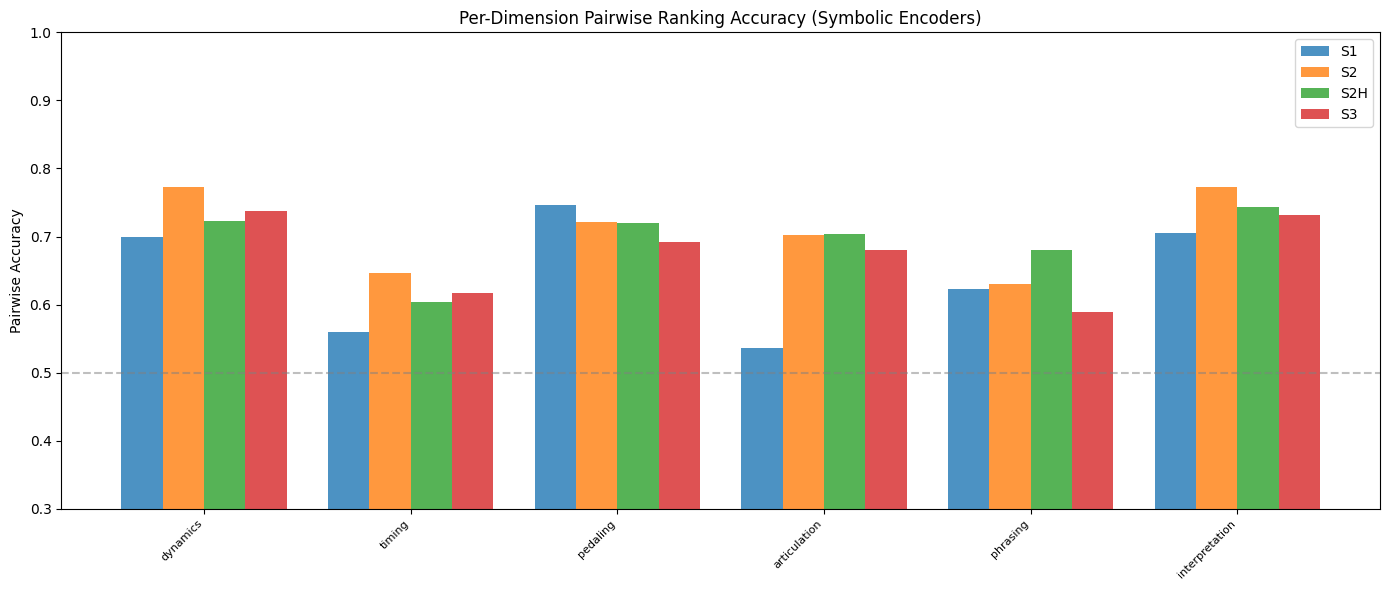

In [39]:
comparison = {}
for name in encoder_config:
    comparison[name] = {}
    if name in all_results:
        comparison[name]['pairwise'] = all_results[name].get('pairwise_mean', 0.0)
        comparison[name]['r2'] = all_results[name].get('r2_mean', 0.0)
    if name in alignment_results:
        comparison[name]['alignment'] = alignment_results[name]['mean_cosine_sim']
    if name in robustness_results:
        comparison[name]['robustness'] = robustness_results[name]['pearson_r']
        comparison[name]['score_drop_pct'] = robustness_results[name]['score_drop_pct']

print(format_comparison_table(comparison))

# Per-dimension bar chart
fig, ax = plt.subplots(1, 1, figsize=(14, 6))
n_dims = NUM_DIMS
x = np.arange(n_dims)
width = 0.2

for i, (name, res) in enumerate(all_results.items()):
    if 'pairwise_detail' not in res:
        continue
    per_dim = res['pairwise_detail']['per_dimension']
    values = [per_dim.get(d, 0.5) for d in range(n_dims)]
    ax.bar(x + i * width, values, width, label=name, alpha=0.8)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(DIMENSIONS, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Pairwise Accuracy')
ax.set_title('Per-Dimension Pairwise Ranking Accuracy (Symbolic Encoders)')
ax.legend()
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax.set_ylim(0.3, 1.0)
plt.tight_layout()
plt.show()

## 14. Winner Selection

Selection protocol:
1. **Primary**: Highest pairwise ranking accuracy
2. **Tiebreak**: Highest R-squared on regression
3. **Veto**: Robustness score_drop_pct > 15% disqualifies
4. **Bonus**: Score alignment (informational)

In [40]:
selection_input = {}
for name, metrics in comparison.items():
    selection_input[name] = {
        'pairwise_mean': metrics.get('pairwise', 0.0),
        'r2_mean': metrics.get('r2', 0.0),
        'score_drop_pct': metrics.get('score_drop_pct', 0.0),
    }

winner = select_winner(selection_input)
print(f'\nWINNER: {winner}')
for name, metrics in comparison.items():
    marker = ' <-- WINNER' if name == winner else ''
    print(f'  {name}: pairwise={metrics.get("pairwise", 0):.4f}, r2={metrics.get("r2", 0):.4f}{marker}')


WINNER: S2
  S1: pairwise=0.6840, r2=0.3282
  S2: pairwise=0.7133, r2=0.3153 <-- WINNER
  S2H: pairwise=0.7016, r2=0.3595
  S3: pairwise=0.7001, r2=0.3721
